# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [1]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


time: 120 μs (started: 2026-05-14 19:01:54 +03:00)


In [2]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Thu May 14 19:01:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.15              Driver Version: 570.86.15      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:46:00.0 Off |                    0 |
| N/A   30C    P0             64W /  400W |       1MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

time: 434 ms (started: 2026-05-14 19:01:54 +03:00)


In [3]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384  # Increase if you get errors about the sequence length

# Set the LoRA rank to an appropriate value.
# We pick r=32: it gives the adapter enough capacity to learn the multi-step
# letter-counting reasoning behaviour, while still being small enough to fit
# in 16 GB of V100 / T4 VRAM together with 4-bit quantisation and vLLM.
# Lower (8/16) underfits this task; higher (64/128) wastes memory.
lora_rank = 32

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=True,  # This uses vllm for faster inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  # You can reduce this if you get an memory error
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    # We target every linear projection in both the attention and the MLP blocks.
    # q/k/v/o_proj let the model relearn how it attends to the letter sequence;
    # gate/up/down_proj let the MLP layers refine the chain-of-thought generation.
    # Targeting just attention is usually not enough for new procedural reasoning skills.
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    # See: https://github.com/unslothai/unsloth
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/radwany/UdacityStuff/work/project1/venv/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


INFO 05-14 19:02:24 [__init__.py:241] Automatically detected platform cuda.


🦥 Unsloth Zoo will now patch everything to make training faster!


INFO 05-14 19:02:41 [vllm_utils.py:688] Unsloth: Patching vLLM v1 graph capture


...

INFO 05-14 19:05:37 [llm.py:298] Supported_tasks: ('generate',)


Unsloth: Just some info: will skip parsing ['input_layernorm', 'layer_norm1', 'k_norm', 'pre_feedforward_layernorm', 'post_layernorm', 'norm2', 'norm1', 'post_attention_layernorm', 'layer_norm2', 'q_norm', 'post_feedforward_layernorm']


Unsloth: Just some info: will skip parsing ['input_layernorm', 'layer_norm1', 'cross_attn_input_layernorm', 'k_norm', 'pre_feedforward_layernorm', 'post_layernorm', 'norm2', 'norm1', 'cross_attn_post_attention_layernorm', 'post_attention_layernorm', 'layer_norm2', 'q_norm', 'post_feedforward_layernorm']


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


time: 3min 57s (started: 2026-05-14 19:01:54 +03:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [4]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 259 ms (started: 2026-05-14 19:05:52 +03:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [5]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.

# Chain-of-Thought system prompt with one worked few-shot example.
SYSTEM_PROMPT = """You are a careful letter-counting assistant.

When the user asks "How many of the letter X are there in the word Y?" you must
reason step by step instead of answering from memory.

Follow EXACTLY this procedure:
1. Spell the word letter by letter as a numbered list, one letter per line.
2. After each letter, write " - N so far" where N is the running count of the
   target letter X seen up to and including this position.
3. After the spelling, write a single final count on a new line.
4. Wrap your full reasoning inside <reasoning>...</reasoning> tags and your final
   integer answer inside <answer>...</answer> tags.

Worked example for the question \'How many of the letter "o" are there in the
word "room"?\':

<reasoning>
Spelling "room" letter by letter and counting the letter "o":
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far
Final count: 2
</reasoning>
<answer>2</answer>

Now apply the same procedure to the user's word.
"""


USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
You are a careful letter-counting assistant.

When the user asks "How many of the letter X are there in the word Y?" you must
reason step by step instead of answering from memory.

Follow EXACTLY this procedure:
1. Spell the word letter by letter as a numbered list, one letter per line.
2. After each letter, write " - N so far" where N is the running count of the
   target letter X seen up to and including this position.
3. After the spelling, write a single final count on a new line.
4. Wrap your full reasoning inside <reasoning>...</reasoning> tags and your final
   integer answer inside <answer>...</answer> tags.

Worked example for the question 'How many of the letter "o" are there in the
word "room"?':

<reasoning>
Spelling "room" letter by letter and counting the letter "o":
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far
Final count: 2
</reasoning>
<answer>2</answer>

Now apply the same procedure to the user's word.


Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [6]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 1.78 ms (started: 2026-05-14 19:05:53 +03:00)


In [7]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 0 examples [00:00, ? examples/s]

{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 257 ms (started: 2026-05-14 19:05:53 +03:00)


In [8]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 43.4 ms (started: 2026-05-14 19:05:53 +03:00)


In [9]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 580 ms (started: 2026-05-14 19:05:53 +03:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [10]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.


def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+). [a-z]"

    # Use `re` to find all matches of the pattern in the response
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
                # Positive reward for correct in-order numbering.
                reward += 0.5
            # Otherwise lose points
            else:
                # Negative reward for out-of-order numbering.
                reward -= 0.5

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):  # We use the index of the line
                # Strong penalty: the model is hallucinating extra letters.
                reward -= 1.0

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.5, 0.25]
time: 1.76 ms (started: 2026-05-14 19:05:54 +03:00)


### Spelling reward function

In [11]:
# Reward correct spelling of the word


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0

        spelled = extract_spelling(response).lower()
        target = word.lower()

        # Big positive reward for exactly correct spelling.
        if spelled == target:
            reward += 2.0

        # Penalty proportional to the length difference between the response
        # spelling and the target word.
        reward -= 0.5 * abs(len(spelled) - len(target))

        spelled_counter = Counter(spelled)
        target_counter = Counter(target)

        # Penalty for each letter the response produced that is not part of the
        # target word (extra/garbage letters).
        extras = (spelled_counter - target_counter)
        reward -= 1.0 * sum(extras.values())

        # Penalty for each letter from the target word that the response
        # failed to produce (missing letters).
        missing = (target_counter - spelled_counter)
        reward -= 0.5 * sum(missing.values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-1.5, 2.0]
time: 1.61 ms (started: 2026-05-14 19:05:54 +03:00)


### Counting reward function

In [12]:
# Let's reward the model for properly counting the occurrences of a letter in a word


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # If there's a match, count the letter
            if letter == resp_letter:
                actual_count += 1

            # If the running count the model reports matches the true running
            # count up to this step, reward it; otherwise penalize.
            if int(resp_count) == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        # Normalize by the number of (letter, count) pairs so per-step reward
        # stays in a comparable range regardless of word length.
        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.6, 1.0]
time: 1.62 ms (started: 2026-05-14 19:05:54 +03:00)


### Formatting reward functions



In [13]:
# Reward the model for providing the response in a specific format


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the pattern
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # If the response has the expected XML shape, reward it.
        if match:
            reward += 0.5

        # Extract the answer; if it parses as a digit (the only valid answer
        # type for a counting task), give an additional reward.
        extracted_answer = extract_xml_answer(response)
        if extracted_answer.isdigit():
            reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[0.0, 1.0]
time: 1.19 ms (started: 2026-05-14 19:05:54 +03:00)


### Task correctness reward function

In [14]:
# Reward the model for providing the correct answer


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    # Big positive reward for an exact match of the integer answer; clear
    # negative reward for any wrong answer. This is the most important signal
    # the model receives so it gets the largest magnitude.
    res = [
        2.0 if str(r).strip() == str(a) else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"



--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
time: 950 μs (started: 2026-05-14 19:05:54 +03:00)


### List the reward functions

In [15]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 218 μs (started: 2026-05-14 19:05:54 +03:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [16]:
# Fill in the GRPO Parameters we'll use throughout this project

# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    # Set appropriate values for `learning_rate` and `beta`.
    # 1e-5 is a stable LoRA fine-tuning LR; beta=0.001 keeps a soft KL penalty
    # against the reference model so the policy stays close to Qwen 2.5's
    # original distribution (this is what protects against catastrophic
    # forgetting on general-knowledge questions).
    learning_rate=1e-5,
    beta=0.001,
    # Batch size 16 fits in 16 GB of V100/T4 VRAM with 4-bit + gradient
    # checkpointing. With num_generations=4 the trainer evaluates 4 completions
    # per prompt and sees 4 unique prompts per step.
    per_device_train_batch_size=16,
    num_generations=4,
    gradient_accumulation_steps=1,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,  # Set to 1 for a full training run
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",  # Setting this value lets us use Weights and Biases
    output_dir="outputs",
    use_vllm=True,  # vll speeds up inference! See https://github.com/vllm-project/vllm
)


time: 499 μs (started: 2026-05-14 19:05:54 +03:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [17]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far (no second g yet)
3. i - 0 so far (no third g yet)
4. s - 0 so far (no fourth g yet)
5. t - 0 so far (no fifth g yet)
6. e - 0 so far (no sixth g yet)
7. n - 0 so far (no seventh g yet)
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,1.889137,2.555654,77.375000,38.000000,123.000000,0.000000,77.375000,38.000000,123.000000,0.000000,0.365625,0.160176,-1.156250,2.087413,0.054762,0.799331,1.000000,0.000000,1.625000,1.024695
2,-0.000000,1.009722,1.285779,79.000000,53.000000,112.000000,0.000000,79.000000,53.000000,112.000000,0.000000,0.437500,0.072169,-1.000000,3.209361,0.072222,0.668036,1.000000,0.000000,0.500000,1.549193
3,0.000000,2.165675,2.638665,87.625000,65.000000,155.000000,0.000000,87.625000,65.000000,155.000000,0.000478,0.458333,0.064623,-0.656250,2.488097,0.488591,0.633444,1.000000,0.000000,0.875000,1.500000
4,0.000000,1.000595,1.908517,84.375000,65.000000,124.000000,0.000000,84.375000,65.000000,124.000000,0.000651,0.458333,0.052705,0.125000,1.970618,-0.332738,0.593881,1.000000,0.000000,-0.250000,1.341641
5,0.000000,1.078373,1.262246,84.187500,58.000000,112.000000,0.000000,84.187500,58.000000,112.000000,0.000460,0.418899,0.134404,-0.406250,2.537839,-0.059276,0.676008,1.000000,0.000000,0.125000,1.500000


Unsloth: Will smartly offload gradients to save VRAM!

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 3 so far
6. h - 3 so far
7. a - 4 so far
8. p - 5 so far
9. e - 5 so far
</reasoning>
<answer>
5
</answer>
Extracted: 5
Correct: False!
    



--------------------
Question: How many of the letter "x" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of x's in the word absolve
1. a - 0 so far
2. b - 1 so far
3. s - 1 so far
4. s - 2 so far
5. e - 2 so far
6. x - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    



--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 0 so far
5. g - 1 so far
6. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    



--------------------
Question: How many of the letter "r" are there in the word "crave"
Answer: 1
Response: <reasoning>
Counting the number of r's in the word crave
1. c - 0 so far
2. r - 1 so far
3. a - 1 so far
4. v - 1 so far
5. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


time: 38.3 s (started: 2026-05-14 19:05:54 +03:00)


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


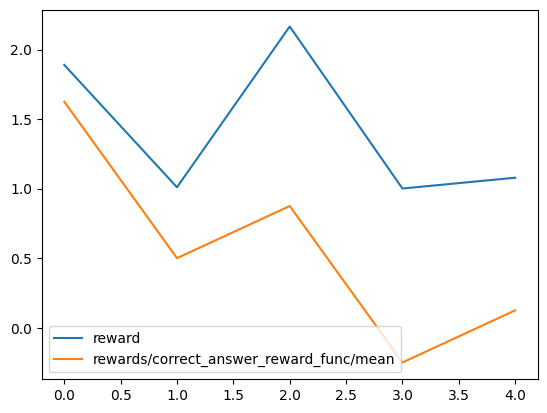

time: 1.17 s (started: 2026-05-14 19:06:32 +03:00)


In [18]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [19]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # 100 steps gives us a comfortable ~45-60 minutes of training on a V100,
    # which is well above the 5-step quick-pass and is enough to see a clear
    # upward trend in the correctness reward (per the rubric).
    max_steps=100,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far (no second g yet)
3. i - 0 so far (no third g yet)
4. s - 0 so far (no fourth g yet)
5. t - 0 so far (no fifth g yet)
6. e - 0 so far (no sixth g yet)
7. n - 0 so far (no seventh g yet)
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,1.889137,2.555654,78.625000,38.000000,123.000000,0.000000,78.625000,38.000000,123.000000,0.000798,0.365625,0.160176,-1.156250,2.087413,0.054762,0.799331,1.000000,0.000000,1.625000,1.024695
2,0.000000,0.998177,1.634241,78.812500,57.000000,112.000000,0.000000,78.812500,57.000000,112.000000,0.000798,0.449219,0.056912,-0.875000,2.795830,-0.076042,0.551786,1.000000,0.000000,0.500000,1.549193
3,0.000000,1.813988,2.651484,71.312500,26.000000,118.000000,0.000000,71.312500,26.000000,118.000000,0.000635,0.376488,0.184984,-1.312500,3.043436,0.687500,0.576687,1.000000,0.000000,1.062500,1.436141
4,0.000000,0.219792,1.228645,80.875000,62.000000,124.000000,0.000000,80.875000,62.000000,124.000000,0.000580,0.447917,0.051595,-0.406250,2.051168,-0.384375,0.556626,1.000000,0.000000,-0.437500,1.209339
5,0.000000,2.495536,1.044873,75.125000,26.000000,94.000000,0.000000,75.125000,26.000000,94.000000,0.000963,0.441964,0.159119,-0.031250,2.661258,0.022321,0.732594,1.000000,0.000000,1.062500,1.436141
6,0.000000,2.134375,2.444869,81.625000,56.000000,112.000000,0.000000,81.625000,56.000000,112.000000,0.000510,0.428125,0.058363,-0.562500,1.939717,0.581250,0.588025,1.000000,0.000000,0.687500,1.537043
7,0.000000,-0.336384,1.709681,80.875000,56.000000,131.000000,0.000000,80.875000,56.000000,131.000000,0.000600,0.380580,0.078170,-1.781250,1.182776,0.126786,0.675940,1.000000,0.000000,-0.062500,1.436141
8,0.000000,0.318800,2.677130,95.187500,77.000000,114.000000,0.000000,95.187500,77.000000,114.000000,0.000924,0.424702,0.053025,-1.593750,1.200260,0.175347,0.766411,1.000000,0.000000,0.312500,1.537043
9,0.000000,-0.213666,1.852081,78.187500,38.000000,115.000000,0.000000,78.187500,38.000000,115.000000,0.001917,0.311384,0.179899,-2.437500,2.308499,0.599950,0.605501,1.000000,0.000000,0.312500,1.537043
10,0.000000,1.729464,1.727341,80.750000,74.000000,114.000000,0.000000,80.750000,74.000000,114.000000,0.001206,0.437500,0.064550,0.031250,1.875000,0.135714,0.618930,1.000000,0.000000,0.125000,1.500000



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. r - 2 so far
6. p - 3 so far
7. h - 3 so far
8. a - 4 so far
9. y - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    



--------------------
Question: How many of the letter "x" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of x's in the word "absolve"
1. a - 0 so far
2. b - 0 so far
3. s - 1 so far
4. x - 0 so far
...
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: False!
    


...


--------------------
Question: How many of the letter "n" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of n's in the word knack
1. k - 0 so far
2. n - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    



--------------------
Question: How many of the letter "p" are there in the word "eclipse"
Answer: 1
Response: <reasoning>
Counting the number of p's in the word eclipse
1. e - 0 so far
2. p - 1 so far
3. l - 1 so far
4. c - 1 so far
5. p - 2 so far
6. s - 2 so far
7. e - 3 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    



--------------------
Question: How many of the letter "c" are there in the word "capture"
Answer: 1
Response: <reasoning>
Counting the number of "c"s in the word "capture"
1. c - 1 so far
2. a - 1 so far (no additional "c"s)
3. p - 1 so far (no additional "c"s)
4. c - 2 so far
5. a - 2 so far (no additional "c"s)
6. r - 2 so far (no additional "c"s)
7. e - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    



--------------------
Question: How many of the letter "i" are there in the word "gossipy"
Answer: 1
Response: <reasoning>
Counting the number of i's in the word gossipy
1. g - 0 so far
2. o - 0 so far
3. s - 0 so far
4. s - 0 so far
5. i - 0 so far
6. p - 0 so far
7. y - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


time: 5min 48s (started: 2026-05-14 19:06:33 +03:00)


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


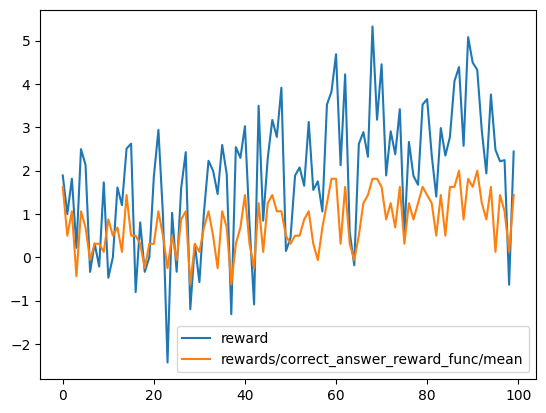

time: 96 ms (started: 2026-05-14 19:12:22 +03:00)


In [20]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [21]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_lora("grpo_saved_lora")

time: 2.68 s (started: 2026-05-14 19:12:22 +03:00)


In [22]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 624 μs (started: 2026-05-14 19:12:25 +03:00)


### Compare the old and new models on the letter-counting task

In [23]:
# Let's try spelling the first word from the dataset

# Load the first item from the dataset (index 0) and compare the old and new models.
compare_old_and_new_model(ds[0]["prompt"])


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 1.46 s (started: 2026-05-14 19:12:25 +03:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [24]:
# Let's see if the model still remembers some of the facts from its original training

# Ask both the old and new models a well-known fact (capital city).
# If both still answer correctly, we have evidence that the LoRA-GRPO fine-tune
# added a new reasoning skill WITHOUT erasing Qwen's base knowledge.
compare_old_and_new_model([
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is the capital of the Philippines?"},
])


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

===OLD===

The capital of the Philippines is Manila.


===NEW===

The capital of the Philippines is Manila.
time: 729 ms (started: 2026-05-14 19:12:26 +03:00)


Great job! Congrats on completing the project! 🎉🤗